# Tasks:
Download the “toxic_comments_dataset.csv” file from LMS with the following link:
https://lms.digiskills.pk/Courses/AIP301/Downloads/toxic_comments_dataset.csv
## Task 1: Dataset Loading and Initial Exploration (Marks: 2)
Load the toxic_comments_dataset.csvdataset using Pandas and display the following:
1. Display the first 10 and last 8 records and check the dataset shape.
2. Display the column names and data types of all columns.
3. Display the statistical summary of the numerical columns.

In [81]:
import numpy as np
import pandas as pd
import re
dataset_path="/kaggle/input/datasets/muhammadilyas1/toxicdata/toxic_comments_dataset.csv"
df=pd.read_csv(dataset_path)
df.head(10)

,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
0,COM000001,The message targets a group unfairly and viola...,Identity_Attack,0,1,0,0,1,0.818,66,10,Community Chat,Sports,High,English
1,COM000002,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.069,58,9,News Comments,Entertainment,High,English
2,COM000003,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.622,44,7,Social Media,Politics,Low,English
3,COM000004,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.010,61,9,Social Media,Entertainment,Low,English
4,COM000005,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.140,52,8,Blog,Sports,Low,English
5,COM000006,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.729,44,7,Social Media,Technology,Low,English
6,COM000007,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.193,52,8,Blog,Entertainment,Low,English
7,COM000008,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.183,61,9,Forum,Gaming,Low,English
8,COM000009,This article provides useful information and c...,Clean,1,0,0,0,0,0.142,60,8,Social Media,Education,Medium,English
9,COM000010,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.153,61,9,Forum,Entertainment,Low,English


In [82]:
df.shape

(30000, 15)

In [83]:
df.size

450000

In [84]:
df.tail(8)

,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
29992,COM029993,Your message is unnecessarily hostile and offe...,Toxic,0,1,0,0,0,0.520,52,7,Forum,Gaming,Medium,English
29993,COM029994,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.195,61,9,News Comments,Sports,Medium,English
29994,COM029995,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.174,58,9,Community Chat,Gaming,Low,English
29995,COM029996,This article provides useful information and c...,Clean,1,0,0,0,0,0.013,60,8,Community Chat,Sports,Medium,English
29996,COM029997,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.050,52,8,Blog,Politics,Medium,English
29997,COM029998,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.078,61,9,Forum,Sports,Low,English
29998,COM029999,This article provides useful information and c...,Clean,1,0,0,0,0,0.003,60,8,Social Media,Sports,Medium,English
29999,COM030000,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.082,61,9,Community Chat,Education,High,English


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Comment_ID           30000 non-null  object 
 1   Comment_Text         30000 non-null  object 
 2   Toxicity_Label       30000 non-null  object 
 3   Clean                30000 non-null  int64  
 4   Toxic                30000 non-null  int64  
 5   Severe_Toxic         30000 non-null  int64  
 6   Threat               30000 non-null  int64  
 7   Identity_Attack      30000 non-null  int64  
 8   Toxicity_Score       30000 non-null  float64
 9   Comment_Length       30000 non-null  int64  
 10  Word_Count           30000 non-null  int64  
 11  Platform             30000 non-null  object 
 12  Topic                30000 non-null  object 
 13  Moderation_Priority  30000 non-null  object 
 14  Language             30000 non-null  object 
dtypes: float64(1), int64(7), object(7)
m

In [86]:
df.describe()

,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.619300,0.380700,0.060033,0.048633,0.048933,0.324542,56.357633,8.340633
std,0.485567,0.485567,0.237553,0.215104,0.215732,0.302914,6.962596,0.972094
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.000000,6.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.079000,52.000000,8.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.161000,58.000000,8.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.624000,61.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.950000,71.000000,11.000000


## Task 2: Text Cleaning, Preprocessing and Data Quality, Target Analysis (Marks: 2)
1. Convert comments to lowercase and handle missing values and duplicate comments.
2. Check the number of duplicate records and display the number of missing values in each column.
3. Clean the comment text by converting it to lowercase and removing tags, punctuation, numbers,
special characters, extra spaces, emojis, and unnecessary whitespace.


In [87]:
df["Comment_Text"].isnull().sum()

np.int64(0)

In [88]:
print(df["Comment_Text"].duplicated().sum())

29983


In [89]:
duplicate_comments = df["Comment_Text"].duplicated().sum()

print("Number of duplicate comments:", duplicate_comments)

Number of duplicate comments: 29983


In [90]:
print("\nNumber of duplicate records:")
print(df.duplicated().sum())


Number of duplicate records:
0


In [91]:
import re
def clean_comment(text):
    text = str(text)
    text = text.lower()
    # Remove HTML/XML tags
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text
df["Comment_Text_Clean"] = df["Comment_Text"].apply(clean_comment)

In [92]:
print("\nOriginal vs Cleaned comments:")
print(df[["Comment_Text", "Comment_Text_Clean"]].head(10).to_string())


Original vs Cleaned comments:
                                                         Comment_Text                                                 Comment_Text_Clean
0  The message targets a group unfairly and violates community rules.  the message targets a group unfairly and violates community rules
1          Thank you for sharing this perspective with the community.          thank you for sharing this perspective with the community
2                        That response is aggressive and not helpful.                        that response is aggressive and not helpful
3       I appreciate your explanation and the discussion was helpful.       i appreciate your explanation and the discussion was helpful
4                I respectfully disagree but I understand your point.                i respectfully disagree but i understand your point
5                        That response is aggressive and not helpful.                        that response is aggressive and not helpful
6         

In [93]:
print("\nFinal dataset shape:", df.shape)


Final dataset shape: (30000, 16)


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Comment_ID           30000 non-null  object 
 1   Comment_Text         30000 non-null  object 
 2   Toxicity_Label       30000 non-null  object 
 3   Clean                30000 non-null  int64  
 4   Toxic                30000 non-null  int64  
 5   Severe_Toxic         30000 non-null  int64  
 6   Threat               30000 non-null  int64  
 7   Identity_Attack      30000 non-null  int64  
 8   Toxicity_Score       30000 non-null  float64
 9   Comment_Length       30000 non-null  int64  
 10  Word_Count           30000 non-null  int64  
 11  Platform             30000 non-null  object 
 12  Topic                30000 non-null  object 
 13  Moderation_Priority  30000 non-null  object 
 14  Language             30000 non-null  object 
 15  Comment_Text_Clean   30000 non-null 

In [95]:
df["Comment_Text"][10]

'This reply contains a threat-like statement and is unsafe.'

In [96]:
df["Comment_Text_Clean"][10]

'this reply contains a threat like statement and is unsafe'

In [97]:
from sklearn.model_selection import train_test_split

X = df["Comment_Text_Clean"]
y = df["Toxicity_Label"]
X_train_text, X_test_text, y_train, y_test = train_test_split(X,y,test_size=0.20,
    random_state=42,stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 24000
Testing samples: 6000


## Task 3: NLP Tokenization and Sequence Padding (Marks: 2)
1. Create a Keras Tokenizer using the training text only.
2. Convert training and testing comments into numerical sequences.
3. Select a suitable maximum sequence length and apply padding/truncation.


In [98]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)
xtrainsequence=tokenizer.texts_to_sequences(X_train_text)

In [99]:
xtrainsequence[0]

[3, 10, 51, 54, 55, 48, 2, 46, 47, 56]

In [100]:
len(tokenizer.word_index)

87

In [101]:
xtestsequence=tokenizer.texts_to_sequences(X_test_text)

In [102]:
xtestsequence[0]

[11, 12, 13, 14, 3, 15, 16, 5, 9]

In [103]:
import numpy as np

sequence_lengths = [len(seq) for seq in xtrainsequence]

print("Minimum:", min(sequence_lengths))
print("Maximum:", max(sequence_lengths))

Minimum: 6
Maximum: 11


In [104]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

xtrain=pad_sequences(xtrainsequence,maxlen=max(sequence_lengths),padding="post")
xtest=pad_sequences(xtestsequence,maxlen=max(sequence_lengths),padding="post")
print("xtrain shape :",xtrain.shape)
print("xtest shape :",xtest.shape)

xtrain shape : (24000, 11)
xtest shape : (6000, 11)


In [105]:
print("Classes:", y_train.unique())
print("Number of classes:", y_train.nunique())

Classes: ['Severe_Toxic' 'Toxic' 'Clean' 'Identity_Attack' 'Threat']
Number of classes: 5


In [106]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['Clean' 'Identity_Attack' 'Severe_Toxic' 'Threat' 'Toxic']
Number of classes: 5


## Task 4: Train and Validation the Deep Learning Model: (Marks: 2)
Using TensorFlow/Keras, build a multi-class Deep Learning model by performing the following tasks:
1. Including Embedding, Model, Dropout, Dense, and Softmax layers.
2. Train the DL model using the training data set using appropriate batch size.
3. Use a validation split and train the model for a suitable number of 10–20 epochs.


In [107]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling1D,Dense,Embedding,Dropout
from tensorflow.keras.utils import to_categorical

MAX_LEN=max(sequence_lengths)
vocab_size = min(10000, len(tokenizer.word_index) + 1) #padding

model = Sequential([
    
    # Embedding layer
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=MAX_LEN
    ),

    # Convert sequence of word vectors into one vector
    GlobalAveragePooling1D(),

    # Prevent overfitting
    Dropout(0.30),

    # Dense hidden layer
    Dense(64, activation="relu"),

    # More regularization
    Dropout(0.30),

    # Output layer
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [108]:
xtrain[0]

array([ 3, 10, 51, 54, 55, 48,  2, 46, 47, 56,  0], dtype=int32)

In [109]:
history = model.fit(
    xtrain,
    y_train_encoded,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    verbose=1
)
model.summary()

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9552 - loss: 0.1643 - val_accuracy: 1.0000 - val_loss: 4.9377e-04
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 5.7595e-05
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 3.5183e-04 - val_accuracy: 1.0000 - val_loss: 1.4853e-05
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 1.7572e-04 - val_accuracy: 1.0000 - val_loss: 5.0765e-06
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 1.0436e-04 - val_accuracy: 1.0000 - val_loss: 2.2993e-06
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 7.8342e-05 - val_accuracy: 1.0000 - val_loss: 9.7960e-07
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 4.2313e-05 - val_accuracy: 1.0000 - val_loss: 4.2525e-07
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (32, 11, 128)          │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (32, 128)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 5)                │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,537 (232.57 KB)

 Trainable params: 19,845 (77.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 39,692 (155.05 KB)

## Task 5: Evaluate, Plotting and Visualize Model Performance (Marks: 2)
1. Create and display a confusion matrix for the test predictions.
2. Evaluate the trained model on the test dataset and display the test accuracy and loss.
3. Generate and display a classification report containing precision, recall, and F1-score for each class.
## NOTE:
After completing all tasks, save the code file at your end. Just capture screenshots of your Python
code and the corresponding outputs and paste them into a single Microsoft Word (.doc/.docx) document for
submission.
No need to send/attach code file; only provide screenshots of the above tasks.

In [110]:
test_loss, test_accuracy = model.evaluate(
    xtest,
    y_test_encoded,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 1.9868213740892315e-09
Test Accuracy: 1.0


Test Loss: 1.9868213740892315e-09
Test Accuracy: 1.0

Confusion Matrix:
[[3716    0    0    0    0]
 [   0  293    0    0    0]
 [   0    0  360    0    0]
 [   0    0    0  292    0]
 [   0    0    0    0 1339]]


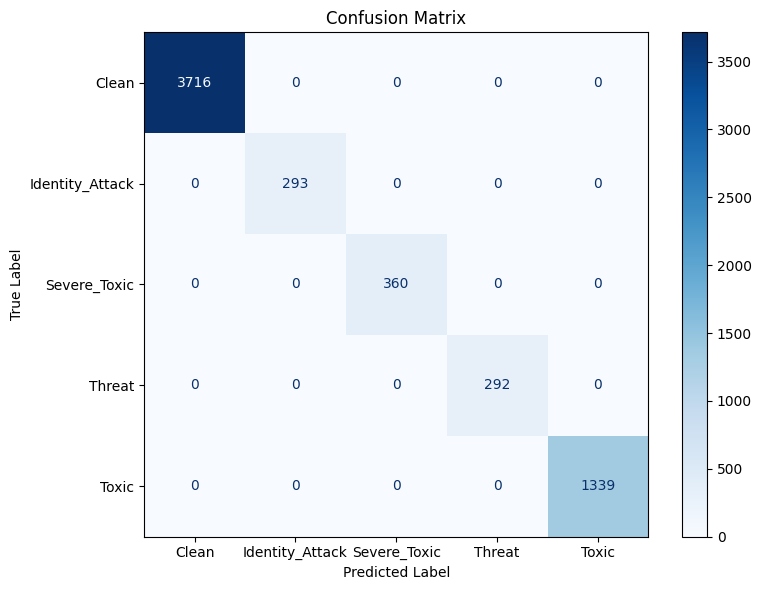


Classification Report:
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3716
Identity_Attack       1.00      1.00      1.00       293
   Severe_Toxic       1.00      1.00      1.00       360
         Threat       1.00      1.00      1.00       292
          Toxic       1.00      1.00      1.00      1339

       accuracy                           1.00      6000
      macro avg       1.00      1.00      1.00      6000
   weighted avg       1.00      1.00      1.00      6000



In [111]:
# Task 5: Evaluate and Visualize Model Performance

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

test_loss, test_accuracy = model.evaluate(
    xtest,
    y_test_encoded,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

y_pred_prob = model.predict(xtest, verbose=0)

# Convert probability predictions into class labels
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



#Classification report

print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)